First of all, we need to install required packages and import all necessary libraries

In [ ]:
!pip install ranx matplotlib pandas numpy

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.0/859.0 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 2.8 MB/s eta 0:00:00
  Created wheel for warc3-wet-clueweb09: filename=warc3_wet_clueweb09-0.2.5-py3-none-any.whl size=18919 sha256=2cee15656a1e0cab3d7a6986ca3f851e03ff6d6912e6fb1824ec0480036096d1
  Stored in directory: /root/.cache/pip/wheels/63/f9/dc/2dd16d3330e327236e4d407941975c42d5159d200cdb7922d8
  Created wheel for cbor: filename=cbor-1.0.0-cp311-cp311-linux_x86_64.whl size=5392

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ranx import Qrels, Run, fuse, evaluate

qrels_path = "/content/drive/MyDrive/IR_FinalAssignment/2019qrels-pass.txt"

run_paths = {
    "MiniLM": "/content/drive/MyDrive/IR_FinalAssignment/ranking_MiniLM.run",
    "TinyBERT": "/content/drive/MyDrive/IR_FinalAssignment/ranking_TinyBERT.run",
    "DistilRoBERTa": "/content/drive/MyDrive/IR_FinalAssignment/ranking_DistilRoBERTa.run"
}

# Define evaluation metrics
metrics = ["ndcg@10", "recall@100", "map@1000"]

Step 1: Load qrels and individual model runs, we need the same data as Task 2 to compare with pairwise combinations

In [ ]:
print("Loading qrels and run files...")
qrels = Qrels.from_file(qrels_path, kind="trec")
runs = {}

for model_name, run_path in run_paths.items():
    print(f"Loading {model_name} run file...")
    runs[model_name] = Run.from_file(run_path, kind="trec")

print("Loaded qrels and run files successfully.")

Loading qrels and run files...
Loading MiniLM run file...
Loading TinyBERT run file...
Loading DistilRoBERTa run file...
Loaded qrels and run files successfully.


Step 2: Select most effective ensemble method (RRF based on Task 2 results)

In [ ]:
best_method = "rrf"
print(f"Selected ensemble method: RRF (Reciprocal Rank Fusion)")

Selected ensemble method: RRF (Reciprocal Rank Fusion)


Step 3: Generate all possible combinations of two models

In [ ]:
model_combinations = [
    ("MiniLM", "TinyBERT"),
    ("MiniLM", "DistilRoBERTa"),
    ("TinyBERT", "DistilRoBERTa")
]

Step 4: Apply RRF to each pair of models

In [ ]:
fusion_results = {}
fusion_runs = {}

for model1, model2 in model_combinations:
    combo_name = f"{model1}+{model2}"
    print(f"Applying RRF fusion to {combo_name}...")

    # Get the two runs to fuse
    runs_to_fuse = [runs[model1], runs[model2]]

    fusion_runs[combo_name] = fuse(
        runs=runs_to_fuse,
        method=best_method,
        norm="min-max"
    )

    # Evaluate results
    fusion_results[combo_name] = evaluate(qrels, fusion_runs[combo_name], metrics)

Applying RRF fusion to MiniLM+TinyBERT...


/usr/local/lib/python3.11/dist-packages/ranx/normalization/min_max_norm.py:44: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  normalized_run[i] = _min_max_norm(run[q_ids[i]], invert)


Applying RRF fusion to MiniLM+DistilRoBERTa...
Applying RRF fusion to TinyBERT+DistilRoBERTa...


Step 5: Create a results table

In [ ]:
individual_results = {}
for model_name, run in runs.items():
    individual_results[model_name] = evaluate(qrels, run, metrics)

all_results = {**individual_results, **fusion_results}
results_df = pd.DataFrame(all_results).T.round(4)

results_df["Type"] = ["Individual" if model in run_paths.keys() else "Fusion"
                      for model in results_df.index]

# Display the results sorted by NDCG@10 (primary metric)
print("\nResults sorted by NDCG@10:")
print(results_df.sort_values("ndcg@10", ascending=False))


Results sorted by NDCG@10:
                        ndcg@10  recall@100  map@1000        Type
MiniLM+DistilRoBERTa     0.7032      0.4985    0.4505      Fusion
MiniLM+TinyBERT          0.7016      0.5065    0.4556      Fusion
TinyBERT+DistilRoBERTa   0.7004      0.5013    0.4600      Fusion
TinyBERT                 0.6919      0.5035    0.4536  Individual
MiniLM                   0.6703      0.4925    0.4288  Individual
DistilRoBERTa            0.6563      0.4727    0.4209  Individual


Step 6: Visualize the results

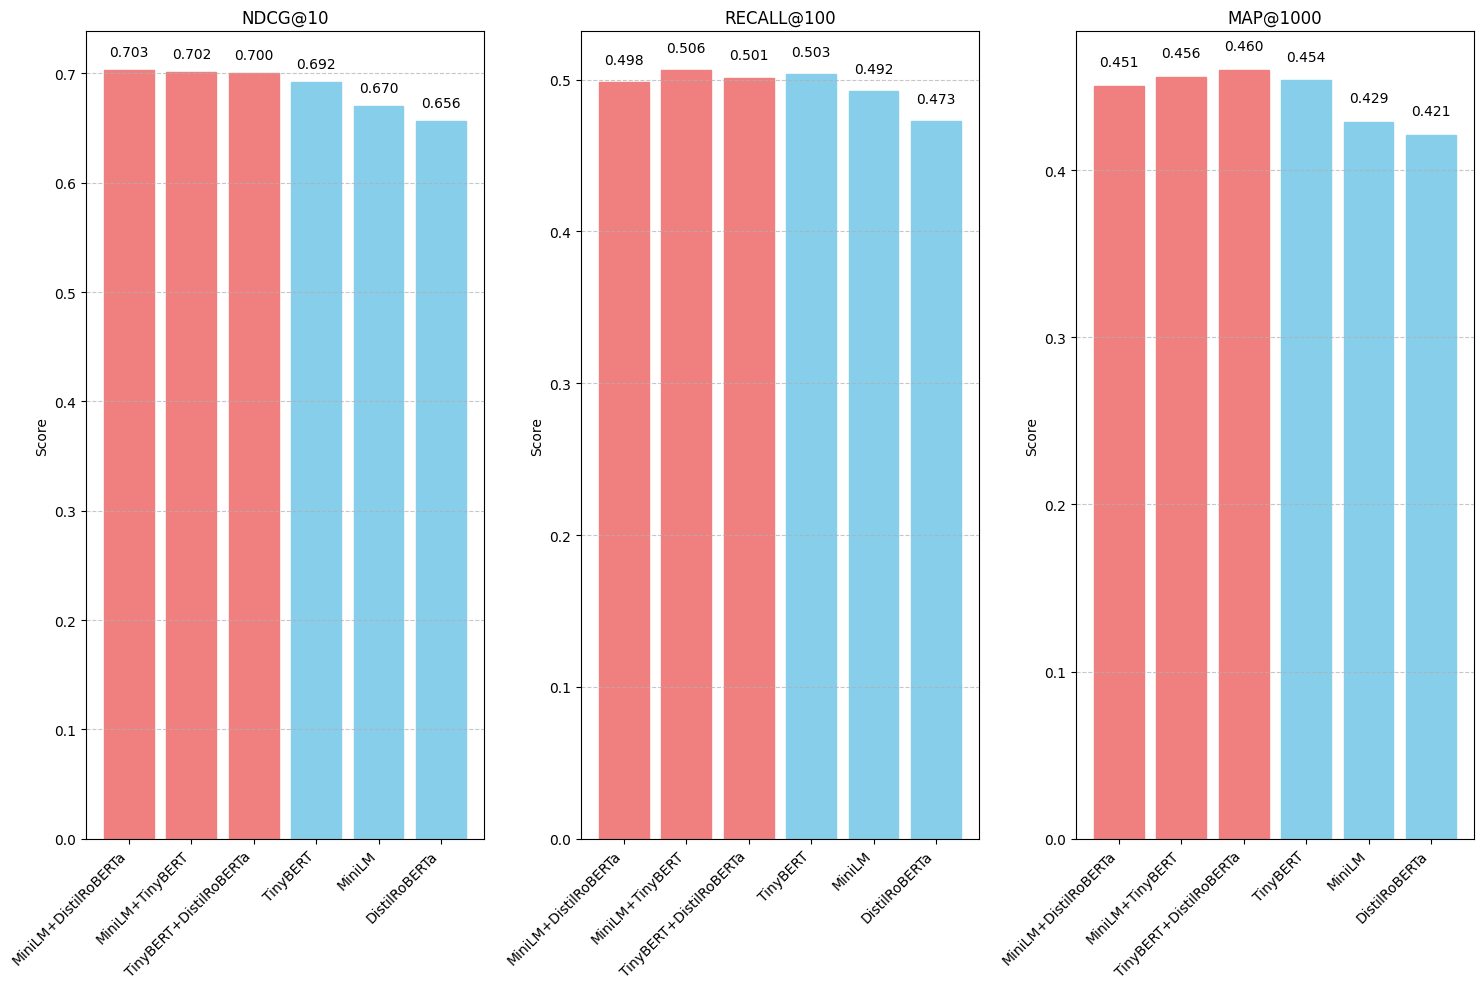

In [ ]:
plt.figure(figsize=(15, 10))

# Sort model names by performance for consistent ordering
models_sorted = results_df.sort_values("ndcg@10", ascending=False).index.tolist()

# Plot each metric
for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i+1)

    metric_results = results_df.loc[models_sorted, metric]

    bars = plt.bar(metric_results.index, metric_results.values)

    for j, bar in enumerate(bars):
        if results_df.loc[models_sorted[j], "Type"] == "Individual":
            bar.set_color('skyblue')
        else:
            bar.set_color('lightcoral')

    plt.title(f"{metric.upper()}")
    plt.ylabel("Score")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height+0.01,
                f'{height:.3f}',
                ha='center', va='bottom', rotation=0)

plt.tight_layout()
plt.savefig('task3_fusion_results.png', dpi=300, bbox_inches='tight')
plt.show()

Step 7: Save fusion runs

In [ ]:
for combo_name, fusion_run in fusion_runs.items():
    output_path = f"/content/drive/MyDrive/IR_FinalAssignment/fusion_RRF_{combo_name.replace('+', '_')}.run"
    fusion_run.save(output_path, kind="trec")
    print(f"Saved fusion run for {combo_name} to {output_path}")

Saved fusion run for MiniLM+TinyBERT to /content/drive/MyDrive/IR_FinalAssignment/fusion_RRF_MiniLM_TinyBERT.run
Saved fusion run for MiniLM+DistilRoBERTa to /content/drive/MyDrive/IR_FinalAssignment/fusion_RRF_MiniLM_DistilRoBERTa.run
Saved fusion run for TinyBERT+DistilRoBERTa to /content/drive/MyDrive/IR_FinalAssignment/fusion_RRF_TinyBERT_DistilRoBERTa.run


Step 8: Analyze which combination performs best

In [ ]:
best_combo = results_df[results_df["Type"] == "Fusion"].sort_values("ndcg@10", ascending=False).index[0]
worst_combo = results_df[results_df["Type"] == "Fusion"].sort_values("ndcg@10").index[0]

print("\n=== Analysis of Model Combinations ===")
print(f"Best combination: {best_combo} with NDCG@10 = {results_df.loc[best_combo, 'ndcg@10']:.4f}")
print(f"Worst combination: {worst_combo} with NDCG@10 = {results_df.loc[worst_combo, 'ndcg@10']:.4f}")

# Check if any pair outperforms the all-three fusion from Task 2
print("\n=== Comparison with Full Ensemble ===")
print(f"Best pair ({best_combo}) NDCG@10: {results_df.loc[best_combo, 'ndcg@10']:.4f}")
print(f"Full ensemble (RRF with all 3 models) NDCG@10: 0.7092")

# Calculate relative improvement of best pair over individual models
m1, m2 = best_combo.split("+")
imp_m1 = (results_df.loc[best_combo, "ndcg@10"] - results_df.loc[m1, "ndcg@10"]) / results_df.loc[m1, "ndcg@10"] * 100
imp_m2 = (results_df.loc[best_combo, "ndcg@10"] - results_df.loc[m2, "ndcg@10"]) / results_df.loc[m2, "ndcg@10"] * 100

print(f"\nThe best pair ({best_combo}) improves NDCG@10 by:")
print(f"- {imp_m1:.2f}% over {m1} alone")
print(f"- {imp_m2:.2f}% over {m2} alone")

# Save the results
results_df.to_csv("/content/drive/MyDrive/IR_FinalAssignment/task3_results.csv")
print("\nTask 3 results saved.")


=== Analysis of Model Combinations ===
Best combination: MiniLM+DistilRoBERTa with NDCG@10 = 0.7032
Worst combination: TinyBERT+DistilRoBERTa with NDCG@10 = 0.7004

=== Comparison with Full Ensemble ===
Best pair (MiniLM+DistilRoBERTa) NDCG@10: 0.7032
Full ensemble (RRF with all 3 models) NDCG@10: 0.7092

The best pair (MiniLM+DistilRoBERTa) improves NDCG@10 by:
- 4.91% over MiniLM alone
- 7.15% over DistilRoBERTa alone

Task 3 results saved to CSV for use in the report.
